# Beam Search 加速差異

## 未加速
使用與 Exact 相同的 Tables

## 加速
加入 CS Table

## 差異

> Note:
> - 考慮兩種方法的 $\lambda$ 取值方式 （$\lambda = 2, 0.5$）

In [1]:
%pip install matplotlib seaborn scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Read csv file
df_dn_beam = pd.read_csv('../DN_beam_target.csv')
df_dn_beam2 = pd.read_csv('../DN_beam2_target.csv')
df_ld_exact = pd.read_csv('../LD_exact_target.csv')

# 2. 檢查第一個檔案 (DN_beam.csv) 的前幾行與基本資訊
print("=== DN_beam.csv 資訊 ===")
display(df_dn_beam.tail())

# 3. 檢查第二個檔案 (DN_beam2.csv) 的前幾行與基本資訊
print("=== DN_beam2.csv 資訊 ===")
display(df_dn_beam2.tail())
print("\n" + "="*50 + "\n")

# 4. 檢查第三個檔案 (LD_exact.csv) 的前幾行與基本資訊
print("=== LD_exact.csv 資訊 ===")
display(df_ld_exact.tail())

=== DN_beam.csv 資訊 ===


,UniPort ID,Protein length,Lambda,MFE,CAI,Run time,cMFE,cCAI,cRun time
55,B2KFW1,1030,0.5,-2197.1,0.775083,242.598,-2192.50,0.781297,0.020498
56,P17040,1043,0.5,-2144.9,0.776466,228.373,-2151.40,0.776466,0.021109
57,Q6NZP1,1069,0.5,-2083.5,0.774075,243.524,-2075.70,0.784973,0.021191
58,A6ZQY2,1076,0.5,-1859.2,0.735650,230.138,-1852.91,0.738479,0.020938
59,P40021,1076,0.5,-1859.2,0.737824,230.602,-1851.60,0.738769,0.020856


=== DN_beam2.csv 資訊 ===


,UniPort ID,Protein length,Lambda,MFE,CAI,Run time,cMFE,cCAI,cRun time
55,B2KFW1,1030,0.5,-2181.0,0.770672,13.4261,-2184.4,0.775643,0.023889
56,P17040,1043,0.5,-2164.6,0.790883,12.4894,-2171.1,0.790883,0.023707
57,Q6NZP1,1069,0.5,-2078.3,0.770263,13.2496,-2079.0,0.770870,0.024694
58,A6ZQY2,1076,0.5,-1828.2,0.738292,12.1072,-1823.7,0.735914,0.023738
59,P40021,1076,0.5,-1823.7,0.732973,12.1128,-1819.2,0.731474,0.023497




=== LD_exact.csv 資訊 ===


,UniPort ID,Protein length,Lambda,MFE,CAI,Run time,cMFE,cCAI,cRun time
55,B2KFW1,1030,2.0,-2211.9,0.873912,1112.60,-2214.7,0.875498,0.506413
56,P17040,1043,2.0,-2099.1,0.896498,1039.87,-2097.8,0.898958,0.493319
57,Q6NZP1,1069,2.0,-2046.6,0.882169,1179.68,-2028.8,0.890442,0.582008
58,A6ZQY2,1076,2.0,-1773.7,0.855450,1026.39,-1767.3,0.859062,0.482646
59,P40021,1076,2.0,-1766.8,0.855289,1029.23,-1760.4,0.858900,0.496209


## 時間差異

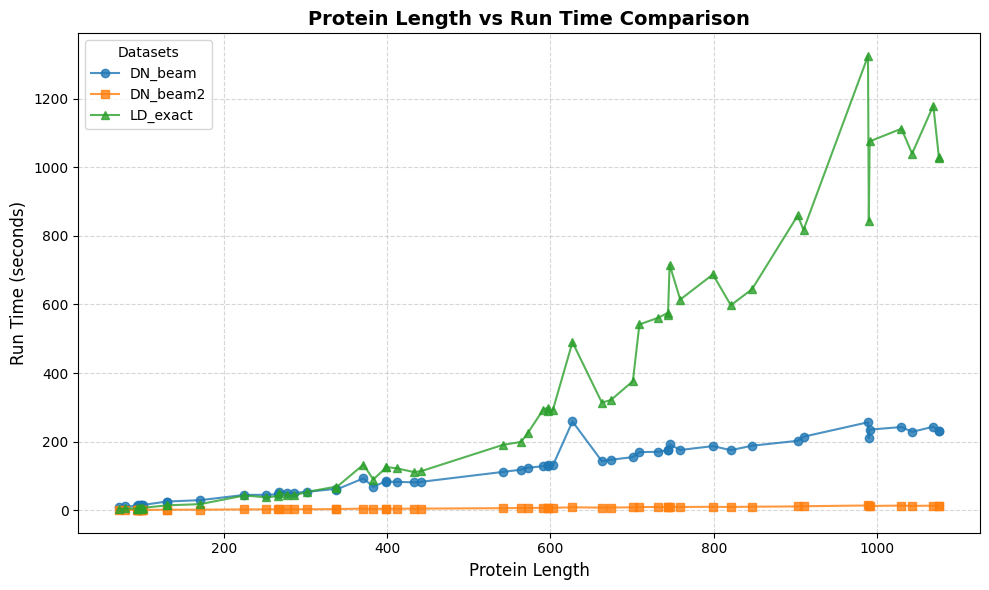

In [3]:
# 1. 確保資料依 X 軸 (Protein length) 進行升序排序，避免線段交叉混亂
df_dn_beam_sorted = df_dn_beam.sort_values(by=" Protein length")
df_dn_beam2_sorted = df_dn_beam2.sort_values(by=" Protein length")
df_ld_exact_sorted = df_ld_exact.sort_values(by=" Protein length")

# 2. 建立圖表與軸物件
fig, ax = plt.subplots(figsize=(10, 6))

# 3. 依序繪製三條線段
ax.plot(
    df_dn_beam_sorted[" Protein length"],
    df_dn_beam_sorted[" Run time"],
    label="DN_beam",
    marker="o",
    linestyle="-",
    alpha=0.8,
)
ax.plot(
    df_dn_beam2_sorted[" Protein length"],
    df_dn_beam2_sorted[" Run time"],
    label="DN_beam2",
    marker="s",
    linestyle="-",
    alpha=0.8,
)
ax.plot(
    df_ld_exact_sorted[" Protein length"],
    df_ld_exact_sorted[" Run time"],
    label="LD_exact",
    marker="^",
    linestyle="-",
    alpha=0.8,
)

# 4. 設定圖表標題、座標軸標籤與格線
ax.set_title(
    "Protein Length vs Run Time Comparison", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Protein Length", fontsize=12)
ax.set_ylabel("Run Time (seconds)", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

# 5. 顯示圖例
ax.legend(title="Datasets", fontsize=10)

# 6. 自動調整邊距並儲存圖片（Notebook 會在單元格下方自動顯示這張圖）
fig.tight_layout()
fig.savefig("protein_runtime_matplotlib.png", dpi=300)

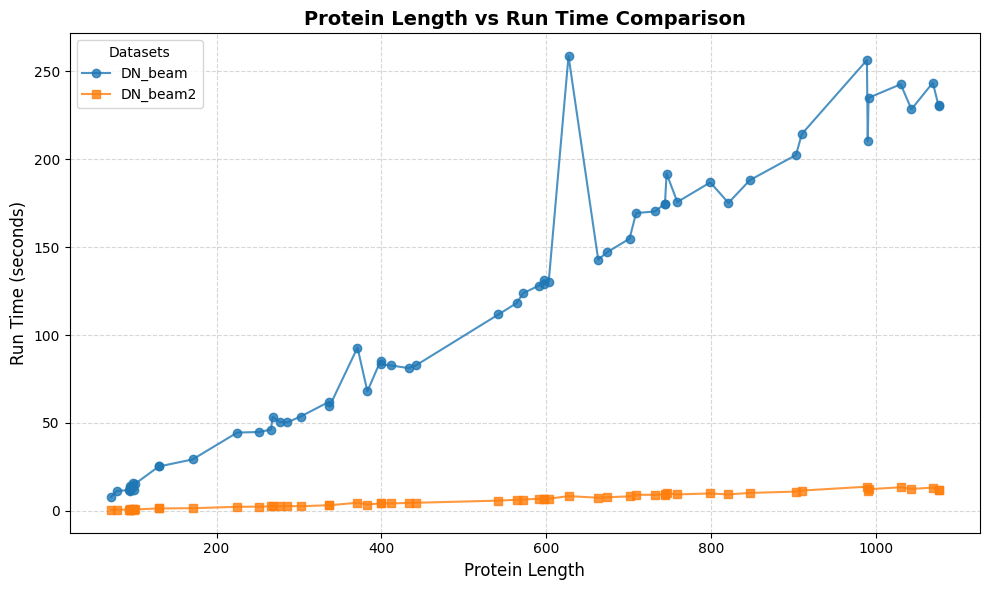

In [11]:
# 1. 確保資料依 X 軸 (Protein length) 進行升序排序，避免線段交叉混亂
df_dn_beam_sorted = df_dn_beam.sort_values(by=" Protein length")
df_dn_beam2_sorted = df_dn_beam2.sort_values(by=" Protein length")
df_ld_exact_sorted = df_ld_exact.sort_values(by=" Protein length")

# 2. 建立圖表與軸物件
fig, ax = plt.subplots(figsize=(10, 6))

# 3. 依序繪製三條線段
ax.plot(
    df_dn_beam_sorted[" Protein length"],
    df_dn_beam_sorted[" Run time"],
    label="DN_beam",
    marker="o",
    linestyle="-",
    alpha=0.8,
)
ax.plot(
    df_dn_beam2_sorted[" Protein length"],
    df_dn_beam2_sorted[" Run time"],
    label="DN_beam2",
    marker="s",
    linestyle="-",
    alpha=0.8,
)

# 4. 設定圖表標題、座標軸標籤與格線
ax.set_title(
    "Protein Length vs Run Time Comparison", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Protein Length", fontsize=12)
ax.set_ylabel("Run Time (seconds)", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

# 5. 顯示圖例
ax.legend(title="Datasets", fontsize=10)

# 6. 自動調整邊距並儲存圖片（Notebook 會在單元格下方自動顯示這張圖）
fig.tight_layout()
fig.savefig("protein_runtime_matplotlib.png", dpi=300)

## MFE & CAI 差異

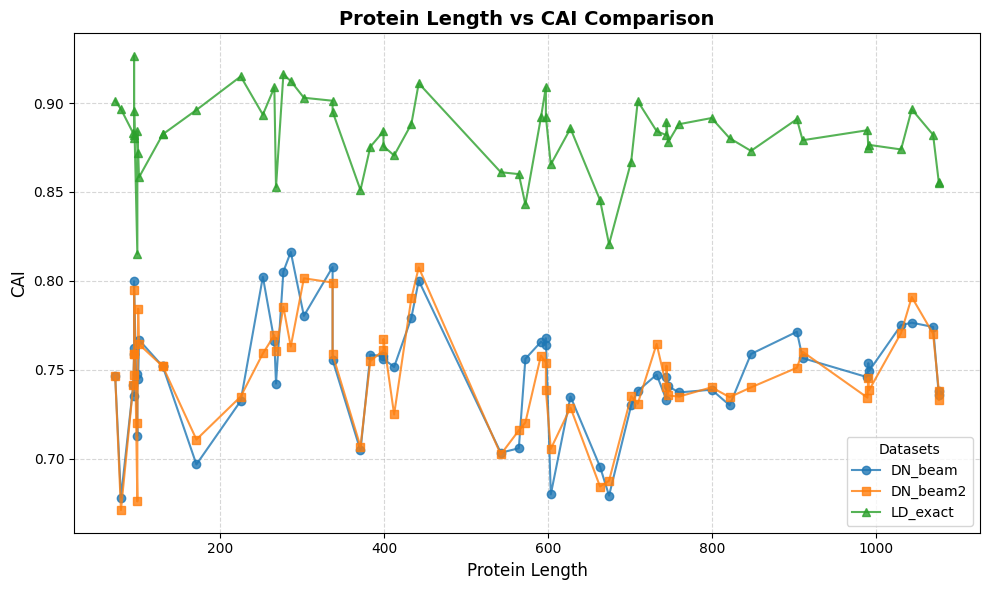

In [4]:
# 1. 確保資料依 X 軸 (Protein length) 進行升序排序，避免線段交叉混亂
df_dn_beam_sorted = df_dn_beam.sort_values(by=" Protein length")
df_dn_beam2_sorted = df_dn_beam2.sort_values(by=" Protein length")
df_ld_exact_sorted = df_ld_exact.sort_values(by=" Protein length")

# 2. 建立圖表與軸物件
fig, ax = plt.subplots(figsize=(10, 6))

# 3. 依序繪製三條線段 (X軸為 Protein length, Y軸為 CAI)
ax.plot(
    df_dn_beam_sorted[" Protein length"],
    df_dn_beam_sorted[" CAI"],
    label="DN_beam",
    marker="o",
    linestyle="-",
    alpha=0.8,
)
ax.plot(
    df_dn_beam2_sorted[" Protein length"],
    df_dn_beam2_sorted[" CAI"],
    label="DN_beam2",
    marker="s",
    linestyle="-",
    alpha=0.8,
)
ax.plot(
    df_ld_exact_sorted[" Protein length"],
    df_ld_exact_sorted[" CAI"],
    label="LD_exact",
    marker="^",
    linestyle="-",
    alpha=0.8,
)

# 4. 設定圖表標題、座標軸標籤與格線
ax.set_title("Protein Length vs CAI Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("Protein Length", fontsize=12)
ax.set_ylabel("CAI", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

# 5. 顯示圖例
ax.legend(title="Datasets", fontsize=10)

# 6. 自動調整邊距並儲存圖片
fig.tight_layout()
fig.savefig("protein_cai_matplotlib.png", dpi=300)

### CAI
**CAI 定義**

$CAI = \left( \prod_{i=1}^{L} w_i \right)^{\frac{1}{L}}$

**用 log 將 連乘 轉換成 連加**
因為直接將所有 CAI 連乘會趨近於 0，所以需要轉成連加

$\log(\mathrm{CAI}) = \frac{1}{L} \sum_{i=1}^{L} \log(w_i)$

**找出 Log Diff (幾何平均的差)**

$\mathrm{Log\_Diff} = \frac{\sum (L \times \log(\mathrm{CAI}_{\mathrm{DN\_beam}}))}{\sum L} - \frac{\sum (L \times \log(\mathrm{CAI}_{\mathrm{DN\_beam2}}))}{\sum L}$

**用 $e^x$ 還原**

$\mathrm{Geometric\ Ratio} = e^{\mathrm{Log\_Diff}}$


In [5]:
# 1. 定義帶有前導空格的欄位名稱
len_col = " Protein length"
cai_col = " CAI"

# 2. 計算 DN_beam 的分子：Sum(長度 * log(CAI)) 以及總長度
# 這裡使用 np.log() 計算自然對數 (ln)
sum_len_log_cai_beam = np.sum(df_dn_beam[len_col] * np.log(df_dn_beam[cai_col]))
total_length_beam = np.sum(df_dn_beam[len_col])

# 計算 DN_beam 長度加權後的平均 log(CAI)
mean_log_cai_beam = sum_len_log_cai_beam / total_length_beam


# 3. 計算 DN_beam2 的分子：Sum(長度 * log(CAI)) 以及總長度
sum_len_log_cai_beam2 = np.sum(
    df_dn_beam2[len_col] * np.log(df_dn_beam2[cai_col])
)
total_length_beam2 = np.sum(df_dn_beam2[len_col])

# 計算 DN_beam2 長度加權後的平均 log(CAI)
mean_log_cai_beam2 = sum_len_log_cai_beam2 / total_length_beam2


# 4. 計算兩個資料集之間的對數差值 (Log_Diff)
log_diff = mean_log_cai_beam - mean_log_cai_beam2

# 5. 透過指數函數 (np.exp) 將對數差值還原，得到幾何平均數比值 (Geometric Ratio)
geometric_ratio = np.exp(log_diff)


# ==========================================
# 輸出計算結果
# ==========================================
print("========== 幾何平均數比值 (Geometric Ratio) 計算結果 ==========")
print(f"DN_beam  的長度加權平均 log(CAI): {mean_log_cai_beam:.6f}")
print(f"DN_beam2 的長度加權平均 log(CAI): {mean_log_cai_beam2:.6f}")
print(f"對數差值 (Log_Diff)            : {log_diff:.6f}")
print("-" * 62)
print(f"最終幾何比值 (Geometric Ratio)  : {geometric_ratio:.4f}")
print("==============================================================")

# 自動根據比值給出直觀的生物學解釋
if geometric_ratio > 1:
    percentage = (geometric_ratio - 1) * 100
    print(
        f"💡 解釋：從密碼子連乘（幾何平均）的角度來看，\n"
        f"   DN_beam 的整體 CAI 表現優於 DN_beam2，約為 DN_beam2 的 {geometric_ratio:.4f} 倍（高出 {percentage:.1f}%）。"
    )
elif geometric_ratio < 1:
    percentage = (1 - geometric_ratio) * 100
    inverse_ratio = 1 / geometric_ratio
    print(
        f"💡 解釋：從密碼子連乘（幾何平均）的角度來看，\n"
        f"   DN_beam2 的整體 CAI 表現優於 DN_beam！\n"
        f"   DN_beam2 約為 DN_beam 的 {inverse_ratio:.4f} 倍（DN_beam 相對低了 {percentage:.1f}%）。"
    )
else:
    print("💡 解釋：兩個資料集的整體幾何平均 CAI 完全相同。")

========== 幾何平均數比值 (Geometric Ratio) 計算結果 ==========
DN_beam  的長度加權平均 log(CAI): -0.291149
DN_beam2 的長度加權平均 log(CAI): -0.294975
對數差值 (Log_Diff)            : 0.003827
--------------------------------------------------------------
最終幾何比值 (Geometric Ratio)  : 1.0038
💡 解釋：從密碼子連乘（幾何平均）的角度來看，
   DN_beam 的整體 CAI 表現優於 DN_beam2，約為 DN_beam2 的 1.00 倍（高出 0.4%）。



========== CAI 分布差異詳細分析 ==========
DN_beam  - CAI 中位數: 0.7504 | 加權 log(CAI) 標準差: 0.0372 | IQR: 0.0302
DN_beam2 - CAI 中位數: 0.7468 | 加權 log(CAI) 標準差: 0.0352 | IQR: 0.0275
-------------------------------------------------------
Wasserstein 距離 (Earth Mover's Distance): 0.004192
K-S 檢定統計量 (KS Statistic)          : 0.1167
K-S 檢定 P 值 (p-value)                 : 8.1328e-01
結論：兩組 CAI 的整體分布在統計上無顯著差異。



/var/folders/dr/2xxj8xrd5y5dz505s9x8h8380000gn/T/ipykernel_49048/1343044118.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


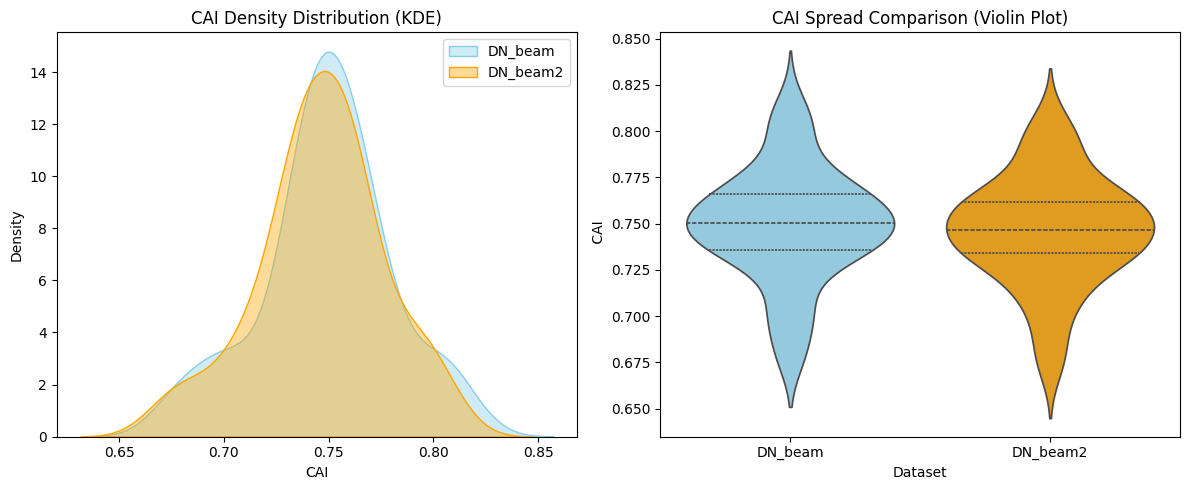

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# ==========================================
# 1. 計算加權標準差 (Weighted Standard Deviation)
# ==========================================
log_cai_beam = np.log(df_dn_beam[cai_col])
log_cai_beam2 = np.log(df_dn_beam2[cai_col])

w_var_beam = np.sum(
    df_dn_beam[len_col] * (log_cai_beam - mean_log_cai_beam) ** 2
) / total_length_beam
w_std_beam = np.sqrt(w_var_beam)

w_var_beam2 = np.sum(
    df_dn_beam2[len_col] * (log_cai_beam2 - mean_log_cai_beam2) ** 2
) / total_length_beam2
w_std_beam2 = np.sqrt(w_var_beam2)

# ==========================================
# 2. 統計檢定與分布距離
# ==========================================
# KS 檢定 (比較分布形狀)
ks_stat, ks_pvalue = stats.ks_2samp(df_dn_beam[cai_col], df_dn_beam2[cai_col])

# Wasserstein 距離 (分布間的物理距離)
wasserstein_dist = stats.wasserstein_distance(
    df_dn_beam[cai_col], df_dn_beam2[cai_col]
)

# ==========================================
# 3. 輸出詳細差異統計
# ==========================================
print("\n========== CAI 分布差異詳細分析 ==========")
print(
    f"DN_beam  - CAI 中位數: {df_dn_beam[cai_col].median():.4f} | 加權 log(CAI) 標準差: {w_std_beam:.4f} | IQR: {stats.iqr(df_dn_beam[cai_col]):.4f}"
)
print(
    f"DN_beam2 - CAI 中位數: {df_dn_beam2[cai_col].median():.4f} | 加權 log(CAI) 標準差: {w_std_beam2:.4f} | IQR: {stats.iqr(df_dn_beam2[cai_col]):.4f}"
)
print("-" * 55)
print(f"Wasserstein 距離 (Earth Mover's Distance): {wasserstein_dist:.6f}")
print(f"K-S 檢定統計量 (KS Statistic)          : {ks_stat:.4f}")
print(f"K-S 檢定 P 值 (p-value)                 : {ks_pvalue:.4e}")

if ks_pvalue < 0.05:
    print("結論：兩組 CAI 的整體分布在統計上有『顯著差異』(p < 0.05)。")
else:
    print("結論：兩組 CAI 的整體分布在統計上無顯著差異。")
print("==========================================\n")

# ==========================================
# 4. 繪製分布圖形進行視覺化確認
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 圖 A: 機率密度分布圖 (KDE Plot)
sns.kdeplot(
    df_dn_beam[cai_col],
    ax=axes[0],
    label="DN_beam",
    fill=True,
    alpha=0.4,
    color="skyblue",
)
sns.kdeplot(
    df_dn_beam2[cai_col],
    ax=axes[0],
    label="DN_beam2",
    fill=True,
    alpha=0.4,
    color="orange",
)
axes[0].set_title("CAI Density Distribution (KDE)")
axes[0].set_xlabel("CAI")
axes[0].set_ylabel("Density")
axes[0].legend()

# 圖 B: 小提琴圖 (Violin Plot)
combined_df = pd.concat(
    [
        df_dn_beam[[cai_col]].assign(Dataset="DN_beam"),
        df_dn_beam2[[cai_col]].assign(Dataset="DN_beam2"),
    ]
)
sns.violinplot(
    data=combined_df,
    x="Dataset",
    y=cai_col,
    ax=axes[1],
    palette=["skyblue", "orange"],
    inner="quartile",
)
axes[1].set_title("CAI Spread Comparison (Violin Plot)")

plt.tight_layout()
plt.show()

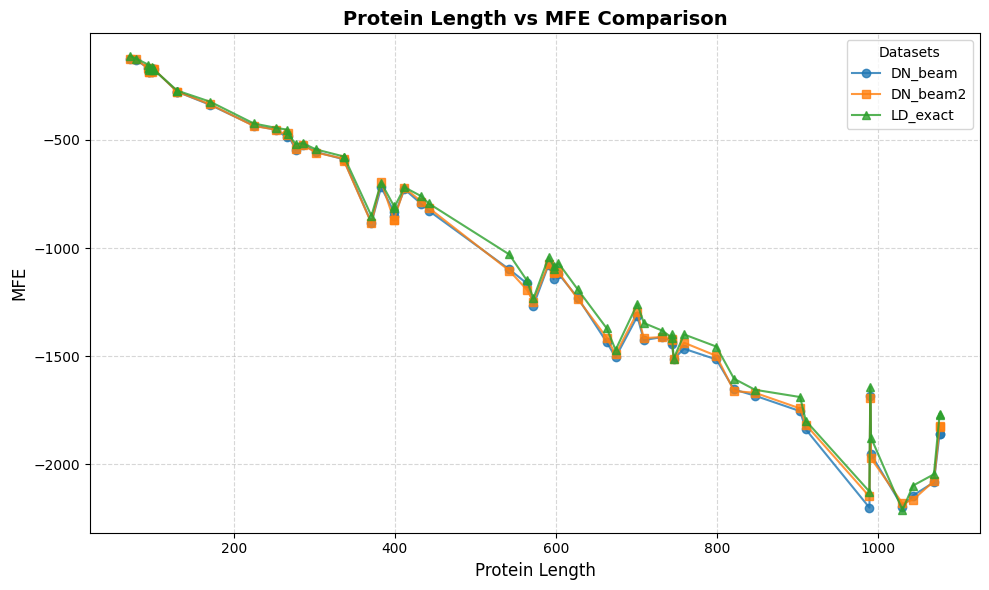

In [7]:
# 1. 確保資料依 X 軸 (Protein length) 進行升序排序，避免線段交叉混亂
df_dn_beam_sorted = df_dn_beam.sort_values(by=" Protein length")
df_dn_beam2_sorted = df_dn_beam2.sort_values(by=" Protein length")
df_ld_exact_sorted = df_ld_exact.sort_values(by=" Protein length")

# 2. 建立圖表與軸物件
fig, ax = plt.subplots(figsize=(10, 6))

# 3. 依序繪製三條線段 (X軸為 Protein length, Y軸為 MFE)
ax.plot(
    df_dn_beam_sorted[" Protein length"],
    df_dn_beam_sorted[" MFE"],
    label="DN_beam",
    marker="o",
    linestyle="-",
    alpha=0.8,
)
ax.plot(
    df_dn_beam2_sorted[" Protein length"],
    df_dn_beam2_sorted[" MFE"],
    label="DN_beam2",
    marker="s",
    linestyle="-",
    alpha=0.8,
)
ax.plot(
    df_ld_exact_sorted[" Protein length"],
    df_ld_exact_sorted[" MFE"],
    label="LD_exact",
    marker="^",
    linestyle="-",
    alpha=0.8,
)

# 4. 設定圖表標題、座標軸標籤與格線
ax.set_title("Protein Length vs MFE Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("Protein Length", fontsize=12)
ax.set_ylabel("MFE", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

# 5. 顯示圖例
ax.legend(title="Datasets", fontsize=10)

# 6. 自動調整邊距並儲存圖片
fig.tight_layout()
fig.savefig("protein_mfe_matplotlib.png", dpi=300)

## MFE
**用 AMFE (Adjusted MFE) 或 MFE Density（自由能密度）比較**

$\mathrm{MFE\ Density} = \frac{\mathrm{MFE}}{\mathrm{Protein\ Length}}$

**我們可以計算每個資料集整體的「平均自由能密度」，然後看 DN_beam 是 DN_beam2 的幾倍（Ratio）**

$\mathrm{Ratio}_{\mathrm{MFE}} = \frac{\text{DN\_beam 的平均 MFE Density}}{\text{DN\_beam2 的平均 MFE Density}}$


In [8]:
# 確保欄位名稱正確（帶前導空格）
len_col = " Protein length"
mfe_col = " MFE"

# ==========================================
# 1. 計算各自的長度加權平均 MFE (Weighted Mean MFE)
# ==========================================
total_len_beam = np.sum(df_dn_beam[len_col])
total_len_beam2 = np.sum(df_dn_beam2[len_col])

weighted_mfe_beam = np.sum(df_dn_beam[len_col] * df_dn_beam[mfe_col]) / total_len_beam
weighted_mfe_beam2 = (
    np.sum(df_dn_beam2[len_col] * df_dn_beam2[mfe_col]) / total_len_beam2
)

mfe_diff = weighted_mfe_beam - weighted_mfe_beam2

# ==========================================
# 2. 計算自由能密度比值 (MFE Density Ratio) -> 推薦科學文獻寫法
# ==========================================
# 算每條序列的 MFE Density，再取算術平均
mfe_density_beam = np.mean(df_dn_beam[mfe_col] / df_dn_beam[len_col])
mfe_density_beam2 = np.mean(df_dn_beam2[mfe_col] / df_dn_beam2[len_col])

mfe_density_ratio = mfe_density_beam / mfe_density_beam2


# ==========================================
# 輸出計算結果
# ==========================================
print("========== MFE 穩定度對比計算結果 ==========")
print(f"DN_beam  的長度加權平均 MFE: {weighted_mfe_beam:.2f}")
print(f"DN_beam2 的長度加權平均 MFE: {weighted_mfe_beam2:.2f}")
print(f"加權平均差值 (DN_beam - beam2): {mfe_diff:.2f}")
print("-" * 50)
print(f"DN_beam  的平均 MFE 密度 (MFE/Length): {mfe_density_beam:.4f}")
print(f"DN_beam2 的平均 MFE 密度 (MFE/Length): {mfe_density_beam2:.4f}")
print(f"最終 MFE 密度比值 (MFE Density Ratio) : {mfe_density_ratio:.4f}")
print("============================================")

# 生物學解釋 (注意：MFE 是負值，越負代表結構越穩定)
print("\n💡 生物學熱力學解釋：")
if mfe_density_beam < mfe_density_beam2:
    percentage = (1 - mfe_density_ratio) * 100
    print(
        f"   DN_beam 的 MFE 密度較低（更負），意味著在相同長度下，\n"
        f"   DN_beam 設計的 RNA 結構比 DN_beam2 更穩定，穩定度高出約 {percentage:.1f}%。"
    )
elif mfe_density_beam > mfe_density_beam2:
    percentage = (mfe_density_ratio - 1) * 100
    print(
        f"   DN_beam2 的 MFE 密度較低（更負），意味著在相同長度下，\n"
        f"   DN_beam2 設計的 RNA 結構比 DN_beam 更穩定！\n"
        f"   DN_beam 的結構穩定度只有 DN_beam2 的 {mfe_density_ratio:.2f} 倍。"
    )
else:
    print("   兩個資料集的整體 MFE 結構穩定度高度一致。")

========== MFE 穩定度對比計算結果 ==========
DN_beam  的長度加權平均 MFE: -1387.57
DN_beam2 的長度加權平均 MFE: -1379.75
加權平均差值 (DN_beam - beam2): -7.83
--------------------------------------------------
DN_beam  的平均 MFE 密度 (MFE/Length): -1.9258
DN_beam2 的平均 MFE 密度 (MFE/Length): -1.9194
最終 MFE 密度比值 (MFE Density Ratio) : 1.0034

💡 生物學熱力學解釋：
   DN_beam 的 MFE 密度較低（更負），意味著在相同長度下，
   DN_beam 設計的 RNA 結構比 DN_beam2 更穩定，穩定度高出約 -0.3%。


## MFECAI 差異

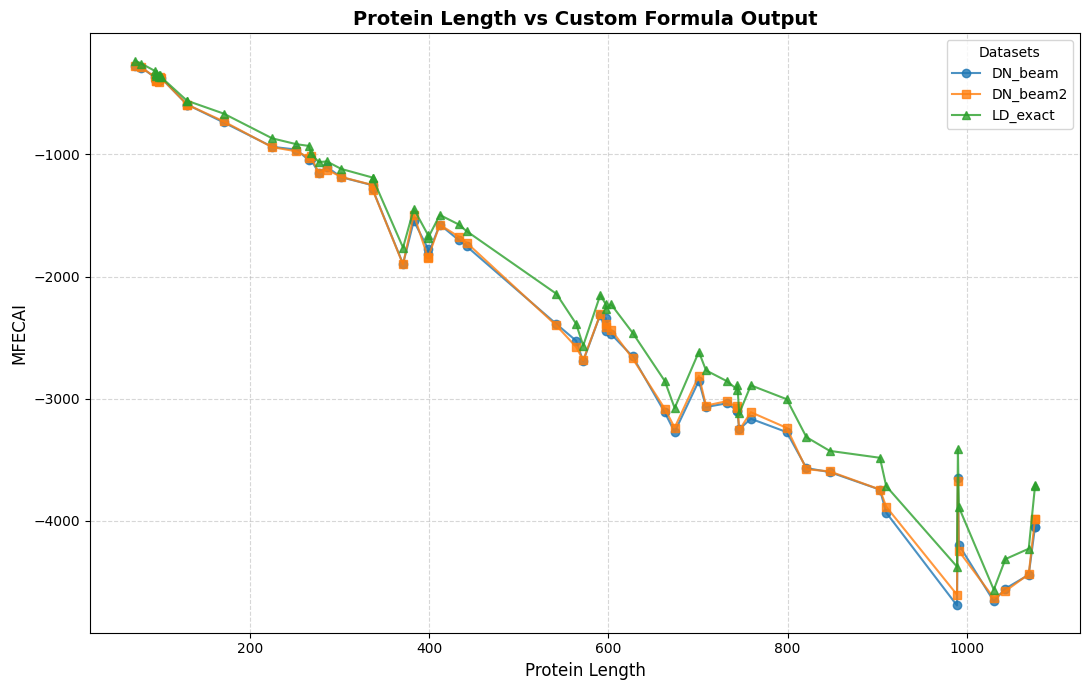

In [9]:
# 1. 定義自訂的 Y 軸計算公式（注意：欄位名稱開頭都有一個空格）
def calculate_custom_y(df, lambda_val=2):
    # 使用 np.log 計算自然對數 (ln)
    cai_log = np.log(df[" CAI"])
    y_values = lambda_val * df[" MFE"] - (1 - lambda_val) * (
        df[" Protein length"] * cai_log
    )
    return y_values


# 2. 先為每個原始 DataFrame 計算出 Y 軸的數值，並存成新欄位 'Custom_Y'
df_dn_beam["Custom_Y"] = calculate_custom_y(df_dn_beam, lambda_val=2)
df_dn_beam2["Custom_Y"] = calculate_custom_y(df_dn_beam2, lambda_val=2)
df_ld_exact["Custom_Y"] = calculate_custom_y(df_ld_exact, lambda_val=2)

# 3. 確保資料依 X 軸 (帶空格的 " Protein length") 進行升序排序，避免線段交叉混亂
df_dn_beam_sorted = df_dn_beam.sort_values(by=" Protein length")
df_dn_beam2_sorted = df_dn_beam2.sort_values(by=" Protein length")
df_ld_exact_sorted = df_ld_exact.sort_values(by=" Protein length")

# 4. 建立圖表與軸物件
fig, ax = plt.subplots(figsize=(11, 7))

# 5. 依序繪製三條線段 (X軸為 " Protein length", Y軸為剛才算好的 "Custom_Y")
ax.plot(
    df_dn_beam_sorted[" Protein length"],
    df_dn_beam_sorted["Custom_Y"],
    label="DN_beam",
    marker="o",
    linestyle="-",
    alpha=0.8,
)
ax.plot(
    df_dn_beam2_sorted[" Protein length"],
    df_dn_beam2_sorted["Custom_Y"],
    label="DN_beam2",
    marker="s",
    linestyle="-",
    alpha=0.8,
)
ax.plot(
    df_ld_exact_sorted[" Protein length"],
    df_ld_exact_sorted["Custom_Y"],
    label="LD_exact",
    marker="^",
    linestyle="-",
    alpha=0.8,
)

# 6. 設定圖表標題、座標軸標籤與格線（Y軸標籤用 LaTeX 格式漂亮呈現）
ax.set_title(
    "Protein Length vs Custom Formula Output", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Protein Length", fontsize=12)
ax.set_ylabel("MFECAI", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

# 7. 顯示圖例
ax.legend(title="Datasets", fontsize=10)

# 8. 自動調整邊距、儲存圖片並顯示
fig.tight_layout()
fig.savefig("protein_custom_formula_matplotlib.png", dpi=300)
plt.show()

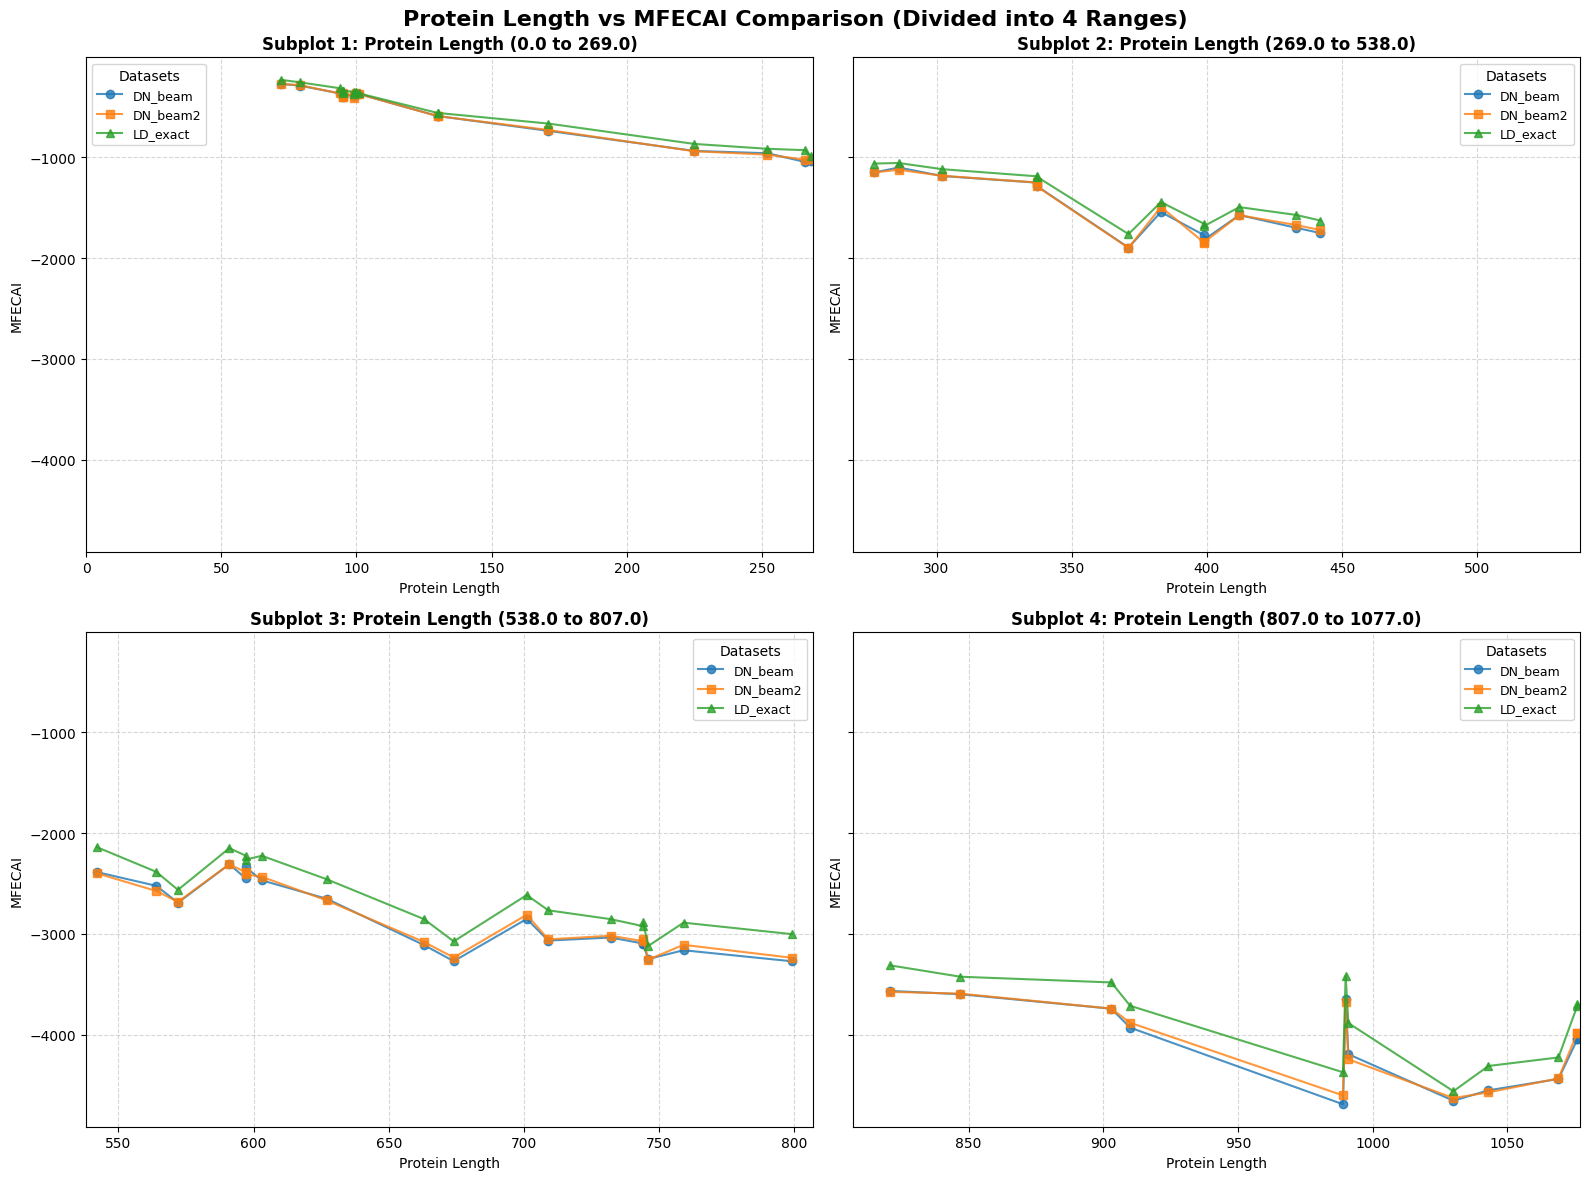

In [10]:
# 1. 定義自訂的 Y 軸計算公式（注意：欄位名稱開頭都有一個空格）
def calculate_custom_y(df, lambda_val=2):
    cai_log = np.log(df[" CAI"])
    y_values = lambda_val * df[" MFE"] - (1 - lambda_val) * (
        df[" Protein length"] * cai_log
    )
    return y_values


# 2. 先為每個原始 DataFrame 計算出 Y 軸的數值，並存成新欄位 'Custom_Y'
df_dn_beam["Custom_Y"] = calculate_custom_y(df_dn_beam, lambda_val=2)
df_dn_beam2["Custom_Y"] = calculate_custom_y(df_dn_beam2, lambda_val=2)
df_ld_exact["Custom_Y"] = calculate_custom_y(df_ld_exact, lambda_val=2)

# 3. 確保資料依 X 軸 (帶空格的 " Protein length") 進行升序排序
df_dn_beam_sorted = df_dn_beam.sort_values(by=" Protein length")
df_dn_beam2_sorted = df_dn_beam2.sort_values(by=" Protein length")
df_ld_exact_sorted = df_ld_exact.sort_values(by=" Protein length")

# ========================================================
# 4. 動態計算 X 軸切分區間 (依據最大長度的 1/4 為單位)
# ========================================================
len_col = " Protein length"
max_len = max(
    df_dn_beam_sorted[len_col].max(),
    df_dn_beam2_sorted[len_col].max(),
    df_ld_exact_sorted[len_col].max(),
)
step = max_len / 4

# 定義 4 個區間的範圍
ranges = [
    (0, step),
    (step, 2 * step),
    (2 * step, 3 * step),
    (3 * step, max_len + 1),  # +1 確保有包含到最後一個端點
]

# ========================================================
# 5. 建立 2x2 的子圖畫布 (四格圖)
# ========================================================
# sharey=True 可以讓四張圖的 Y 軸刻度保持一致，方便互相比較。若不需要請改為 False。
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes_flat = axes.flatten()  # 將 2x2 矩陣拉平為一維陣列 [0, 1, 2, 3]，方便迴圈處理

# 找出全域 Y 軸最大最小值（用於精準控制圖表邊界，若 sharey=True 則非必要，但能讓畫面更好看）
all_y = np.concatenate(
    [
        df_dn_beam_sorted["Custom_Y"],
        df_dn_beam2_sorted["Custom_Y"],
        df_ld_exact_sorted["Custom_Y"],
    ]
)
y_min, y_max = all_y.min(), all_y.max()
y_padding = (y_max - y_min) * 0.05  # 上下留 5% 空白避免遮擋標記

# 6. 開始依序繪製 4 個區間的圖表
for i, (start, end) in enumerate(ranges):
    ax = axes_flat[i]

    # 根據目前的 X 軸區間過濾三個資料集的數據
    b_sub = df_dn_beam_sorted[
        (df_dn_beam_sorted[len_col] >= start)
        & (df_dn_beam_sorted[len_col] < end)
    ]
    b2_sub = df_dn_beam2_sorted[
        (df_dn_beam2_sorted[len_col] >= start)
        & (df_dn_beam2_sorted[len_col] < end)
    ]
    ld_sub = df_ld_exact_sorted[
        (df_ld_exact_sorted[len_col] >= start)
        & (df_ld_exact_sorted[len_col] < end)
    ]

    # 繪製線段
    ax.plot(
        b_sub[len_col],
        b_sub["Custom_Y"],
        label="DN_beam",
        marker="o",
        linestyle="-",
        alpha=0.8,
    )
    ax.plot(
        b2_sub[len_col],
        b2_sub["Custom_Y"],
        label="DN_beam2",
        marker="s",
        linestyle="-",
        alpha=0.8,
    )
    ax.plot(
        ld_sub[len_col],
        ld_sub["Custom_Y"],
        label="LD_exact",
        marker="^",
        linestyle="-",
        alpha=0.8,
    )

    # 設定個別子圖的屬性
    ax.set_title(
        f"Subplot {i+1}: Protein Length ({start:.1f} to {end:.1f})",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Protein Length", fontsize=10)
    ax.set_ylabel("MFECAI", fontsize=10)
    ax.set_xlim(start, end)
    ax.set_ylim(y_min - y_padding, y_max + y_padding)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(title="Datasets", fontsize=9, loc="best")

# 7. 設定大圖表的總標題
fig.suptitle(
    "Protein Length vs MFECAI Comparison (Divided into 4 Ranges)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

# 8. 自動調整邊距、儲存圖片並顯示
fig.tight_layout()
fig.savefig("protein_custom_formula_4_subplots.png", dpi=300)
plt.show()

## 結論

加入 `CS` table 的 beam2
- 在時間上有顯著差異
- 在 CAI, MFE, MFECAI 上皆無顯著差異（結果在可接受範圍內）

故 beam2 相對於 beam 更好